# CNOT sheetcopy
This file contains analysis for CNOT sheetcopy results (both the initial scan and the full scan).

### Initial scan

In [2]:
# initial scan
import numpy as np
import re
from pathlib import Path

data_dir = Path("../results/cnot_sheetcopy/initial_scan")
expected_p_values = np.array([0.006, 0.008, 0.010, 0.012, 0.014, 0.016])
expected_L_values = np.array([5, 7, 9, 13])
expected_repeats = 1

result_paths = sorted(data_dir.rglob("2d_CNOT_*_Ft*.txt"))
if not result_paths:
    raise FileNotFoundError(f"No CNOT Ft result files found under {data_dir.resolve()}. Run cnot_full_scan.sh first, or change data_dir to another scan folder.")

def parse_scalar(text, name, path):
    match = re.search(rf"^{name}\s*=\s*(?:\[([^\]]+)\]|([^\s#]+))\s*$", text, re.MULTILINE)
    if match is None:
        raise ValueError(f"Could not parse {name} from {path}")
    value_text = match.group(1) or match.group(2)
    values = np.fromstring(value_text, sep=" ")
    return float(values[0]) if values.size else float(value_text)

def load_cnot_ft_result(path):
    text = path.read_text()
    l_match = re.search(r"^L\s*=\s*(\d+)\s*$", text, re.MULTILINE)
    p_match = re.search(r"^p\s*=\s*([0-9.]+)\s*$", text, re.MULTILINE)
    if l_match is None or p_match is None:
        raise ValueError(f"Could not parse L/p params from {path}")

    ft = parse_scalar(text, "CNOT_Ft", path)
    trials = parse_scalar(text, "trials", path)
    return int(l_match.group(1)), float(p_match.group(1)), ft, trials

all_records = [load_cnot_ft_result(path) for path in result_paths]
L_values = expected_L_values
p_values = expected_p_values

def is_requested_record(record):
    cur_l, cur_p, *_ = record
    return np.any(L_values == cur_l) and np.any(np.isclose(p_values, cur_p))

records = [record for record in all_records if is_requested_record(record)]
ignored_count = len(all_records) - len(records)
if not records:
    raise ValueError("No CNOT Ft result files matched the requested expected_L_values/expected_p_values.")

Ft_successes = np.zeros((len(L_values), len(p_values)))
Ft_trials = np.zeros_like(Ft_successes)
Ft_rep_count = np.zeros_like(Ft_successes, dtype=int)

for cur_l, cur_p, ft, trials in records:
    l_idx = np.where(L_values == cur_l)[0][0]
    p_idx = np.where(np.isclose(p_values, cur_p))[0][0]
    Ft_successes[l_idx, p_idx] += ft * trials
    Ft_trials[l_idx, p_idx] += trials
    Ft_rep_count[l_idx, p_idx] += 1

missing_mask = Ft_rep_count == 0
if np.any(missing_mask):
    missing = [(int(L_values[i]), float(p_values[j])) for i, j in np.argwhere(missing_mask)]
    print(f"Warning: missing requested CNOT Ft data for these (L, p) points; leaving them as NaN: {missing}")

nonzero_rep_counts = Ft_rep_count[Ft_rep_count > 0]

if np.unique(nonzero_rep_counts).size > 1:
    print("Warning: not every (L, p) point has the same number of repeats.")

if expected_repeats is not None and np.any(nonzero_rep_counts != expected_repeats):
    print(f"Warning: expected {expected_repeats} repeats per (L, p) point.")

Ft_mean = np.divide(Ft_successes, Ft_trials, out=np.full_like(Ft_successes, np.nan), where=Ft_trials > 0)
error_rate = 1 - Ft_mean
error_rate_variance = np.divide(error_rate * (1 - error_rate), Ft_trials, out=np.full_like(error_rate, np.nan), where=Ft_trials > 0)
error_rate_error = np.sqrt(error_rate_variance)

p_grid, L_grid = np.meshgrid(p_values, L_values)
fit_mask = np.isfinite(error_rate) & np.isfinite(error_rate_error) & (error_rate_error > 0)
p = p_grid[fit_mask]
L = L_grid[fit_mask]
rate = error_rate[fit_mask]
rate_error = error_rate_error[fit_mask]

print(f"Loaded {len(records)} requested CNOT Ft files; ignored {ignored_count} files outside the requested lists")
print("L values:", L_values)
print("p values:", p_values)
print("repeat counts:\n", Ft_rep_count)


Loaded 24 requested CNOT Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13]
p values: [0.006 0.008 0.01  0.012 0.014 0.016]
repeat counts:
 [[1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]]


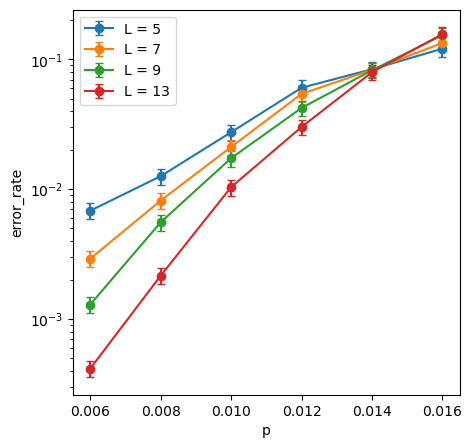

In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.figure(figsize=(5, 5))
for l_idx, cur_l in enumerate(L_values):
    plt.errorbar(p_values, error_rate[l_idx], yerr=error_rate_error[l_idx], fmt="o-", capsize=3, label=f"L = {cur_l}")
    
plt.yscale("log")
plt.xlabel("p")
plt.ylabel("error_rate")
plt.legend()
plt.show()


### Full scan

In [11]:
# full scan
import numpy as np
import re
from pathlib import Path

data_dir = Path("../results/cnot_sheetcopy/full_scan/T∕2_CNOT_T∕2_2T")
expected_p_values = np.array([0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.020])
expected_L_values = np.array([5, 7, 9, 13, 19])
expected_repeats = 5

result_paths = sorted(data_dir.rglob("2d_CNOT_*_Ft*.txt"))
if not result_paths:
    raise FileNotFoundError(f"No CNOT Ft result files found under {data_dir.resolve()}. Run cnot_full_scan.sh first, or change data_dir to another scan folder.")

def parse_scalar(text, name, path):
    match = re.search(rf"^{name}\s*=\s*(?:\[([^\]]+)\]|([^\s#]+))\s*$", text, re.MULTILINE)
    if match is None:
        raise ValueError(f"Could not parse {name} from {path}")
    value_text = match.group(1) or match.group(2)
    values = np.fromstring(value_text, sep=" ")
    return float(values[0]) if values.size else float(value_text)

def load_cnot_ft_result(path):
    text = path.read_text()
    l_match = re.search(r"^L\s*=\s*(\d+)\s*$", text, re.MULTILINE)
    p_match = re.search(r"^p\s*=\s*([0-9.]+)\s*$", text, re.MULTILINE)
    if l_match is None or p_match is None:
        raise ValueError(f"Could not parse L/p params from {path}")

    ft = parse_scalar(text, "CNOT_Ft", path)
    trials = parse_scalar(text, "trials", path)
    return int(l_match.group(1)), float(p_match.group(1)), ft, trials

all_records = [load_cnot_ft_result(path) for path in result_paths]
L_values = expected_L_values
p_values = expected_p_values

def is_requested_record(record):
    cur_l, cur_p, *_ = record
    return np.any(L_values == cur_l) and np.any(np.isclose(p_values, cur_p))

records = [record for record in all_records if is_requested_record(record)]
ignored_count = len(all_records) - len(records)
if not records:
    raise ValueError("No CNOT Ft result files matched the requested expected_L_values/expected_p_values.")

Ft_successes = np.zeros((len(L_values), len(p_values)))
Ft_trials = np.zeros_like(Ft_successes)
Ft_rep_count = np.zeros_like(Ft_successes, dtype=int)

for cur_l, cur_p, ft, trials in records:
    l_idx = np.where(L_values == cur_l)[0][0]
    p_idx = np.where(np.isclose(p_values, cur_p))[0][0]
    Ft_successes[l_idx, p_idx] += ft * trials
    Ft_trials[l_idx, p_idx] += trials
    Ft_rep_count[l_idx, p_idx] += 1

missing_mask = Ft_rep_count == 0
if np.any(missing_mask):
    missing = [(int(L_values[i]), float(p_values[j])) for i, j in np.argwhere(missing_mask)]
    print(f"Warning: missing requested CNOT Ft data for these (L, p) points; leaving them as NaN: {missing}")

nonzero_rep_counts = Ft_rep_count[Ft_rep_count > 0]

if np.unique(nonzero_rep_counts).size > 1:
    print("Warning: not every (L, p) point has the same number of repeats.")

if expected_repeats is not None and np.any(nonzero_rep_counts != expected_repeats):
    print(f"Warning: expected {expected_repeats} repeats per (L, p) point.")

Ft_mean = np.divide(Ft_successes, Ft_trials, out=np.full_like(Ft_successes, np.nan), where=Ft_trials > 0)
error_rate = 1 - Ft_mean
error_rate_variance = np.divide(error_rate * (1 - error_rate), Ft_trials, out=np.full_like(error_rate, np.nan), where=Ft_trials > 0)
error_rate_error = np.sqrt(error_rate_variance)

p_grid, L_grid = np.meshgrid(p_values, L_values)
fit_mask = np.isfinite(error_rate) & np.isfinite(error_rate_error) & (error_rate_error > 0)
p = p_grid[fit_mask]
L = L_grid[fit_mask]
rate = error_rate[fit_mask]
rate_error = error_rate_error[fit_mask]

print(f"Loaded {len(records)} requested CNOT Ft files; ignored {ignored_count} files outside the requested lists")
print("L values:", L_values)
print("p values:", p_values)
print("repeat counts:\n", Ft_rep_count)


Loaded 250 requested CNOT Ft files; ignored 40 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5]]


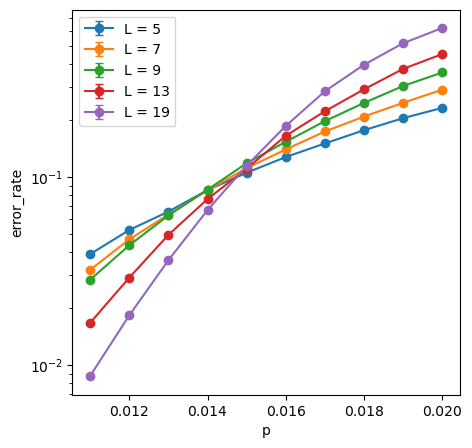

In [12]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.figure(figsize=(5, 5))
for l_idx, cur_l in enumerate(L_values):
    plt.errorbar(p_values, error_rate[l_idx], yerr=error_rate_error[l_idx], fmt="o-", capsize=3, label=f"L = {cur_l}")
    
plt.yscale("log")
plt.xlabel("p")
plt.ylabel("error_rate")
plt.legend()
plt.show()


In [ ]:
p_grid, L_grid = np.meshgrid(p_values, L_values)
fit_mask = np.isfinite(error_rate) & np.isfinite(error_rate_error) & (error_rate_error > 0)
p = p_grid[fit_mask]
L = L_grid[fit_mask]
rate = error_rate[fit_mask]
rate_error = error_rate_error[fit_mask]


In [ ]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True, maxfev=100000)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

In [ ]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True, maxfev=100000)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

In [ ]:
# Define the model
def model(pL, pc, nu, A, B, C, E, mu):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + E*(L**(-1/mu))

lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0]
upper_bounds = [ np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf, 100]

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0, 1], full_output=True, sigma=rate_error, absolute_sigma=True, bounds=(lower_bounds, upper_bounds), maxfev=100000)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

In [ ]:
# Define the model
def model(pL, pc, nu, A, B, C, D, E, mu):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu)) + E*(L**(-1/mu))

lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0]
upper_bounds = [ np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf, 100]

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0, 0, 1], full_output=True, sigma=rate_error, absolute_sigma=True, bounds=(lower_bounds, upper_bounds), maxfev=100000)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

In [ ]:
px = 0.16
w1 = np.log(1/px - 1)
print(w1)